In [ ]:
from collections import defaultdict
import json
import glob, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INSTRUMENT_PREFIXES = {"chestnut", "confine", "sysfilter_extract", "syspart", "syspart_new", "go2seccomp"}

SYSCALL_MAP = {
    0:"read",
    1:"write",
    2:"open",
    3:"close",
    4:"stat",
    5:"fstat",
    6:"lstat",
    7:"poll",
    8:"lseek",
    9:"mmap",
    10:"mprotect",
    11:"munmap",
    12:"brk",
    13:"rt_sigaction",
    14:"rt_sigprocmask",
    15:"rt_sigreturn",
    16:"ioctl",
    17:"pread",
    18:"pwrite",
    19:"readv",
    20:"writev",
    21:"access",
    22:"pipe",
    23:"select",
    24:"sched_yield",
    25:"mremap",
    26:"msync",
    27:"mincore",
    28:"madvise",
    29:"shmget",
    30:"shmat",
    31:"shmctl",
    32:"dup",
    33:"dup2",
    34:"pause",
    35:"nanosleep",
    36:"getitimer",
    37:"alarm",
    38:"setitimer",
    39:"getpid",
    40:"sendfile",
    41:"socket",
    42:"connect",
    43:"accept",
    44:"sendto",
    45:"recvfrom",
    46:"sendmsg",
    47:"recvmsg",
    48:"shutdown",
    49:"bind",
    50:"listen",
    51:"getsockname",
    52:"getpeername",
    53:"socketpair",
    54:"setsockopt",
    55:"getsockopt",
    56:"clone",
    57:"fork",
    58:"vfork",
    59:"execve",
    60:"exit",
    61:"wait4",
    62:"kill",
    63:"uname",
    64:"semget",
    65:"semop",
    66:"semctl",
    67:"shmdt",
    68:"msgget",
    69:"msgsnd",
    70:"msgrcv",
    71:"msgctl",
    72:"fcntl",
    73:"flock",
    74:"fsync",
    75:"fdatasync",
    76:"truncate",
    77:"ftruncate",
    78:"getdents",
    79:"getcwd",
    80:"chdir",
    81:"fchdir",
    82:"rename",
    83:"mkdir",
    84:"rmdir",
    85:"creat",
    86:"link",
    87:"unlink",
    88:"symlink",
    89:"readlink",
    90:"chmod",
    91:"fchmod",
    92:"chown",
    93:"fchown",
    94:"lchown",
    95:"umask",
    96:"gettimeofday",
    97:"getrlimit",
    98:"getrusage",
    99:"sysinfo",
    100:"times",
    101:"ptrace",
    102:"getuid",
    103:"syslog",
    104:"getgid",
    105:"setuid",
    106:"setgid",
    107:"geteuid",
    108:"getegid",
    109:"setpgid",
    110:"getppid",
    111:"getpgrp",
    112:"setsid",
    113:"setreuid",
    114:"setregid",
    115:"getgroups",
    116:"setgroups",
    117:"setresuid",
    118:"getresuid",
    119:"setresgid",
    120:"getresgid",
    121:"getpgid",
    122:"setfsuid",
    123:"setfsgid",
    124:"getsid",
    125:"capget",
    126:"capset",
    127:"rt_sigpending",
    128:"rt_sigtimedwait",
    129:"rt_sigqueueinfo",
    130:"rt_sigsuspend",
    131:"sigaltstack",
    132:"utime",
    133:"mknod",
    134:"uselib",
    135:"personality",
    136:"ustat",
    137:"statfs",
    138:"fstatfs",
    139:"sysfs",
    140:"getpriority",
    141:"setpriority",
    142:"sched_setparam",
    143:"sched_getparam",
    144:"sched_setscheduler",
    145:"sched_getscheduler",
    146:"sched_get_priority_max",
    147:"sched_get_priority_min",
    148:"sched_rr_get_interval",
    149:"mlock",
    150:"munlock",
    151:"mlockall",
    152:"munlockall",
    153:"vhangup",
    154:"modify_ldt",
    155:"pivot_root",
    156:"_sysctl",
    157:"prctl",
    158:"arch_prctl",
    159:"adjtimex",
    160:"setrlimit",
    161:"chroot",
    162:"sync",
    163:"acct",
    164:"settimeofday",
    165:"mount",
    166:"umount2",
    167:"swapon",
    168:"swapoff",
    169:"reboot",
    170:"sethostname",
    171:"setdomainname",
    172:"iopl",
    173:"ioperm",
    174:"create_module",
    175:"init_module",
    176:"delete_module",
    177:"get_kernel_syms",
    178:"query_module",
    179:"quotactl",
    180:"nfsservctl",
    181:"getpmsg",
    182:"putpmsg",
    183:"afs_syscall",
    184:"tuxcall",
    185:"security",
    186:"gettid",
    187:"readahead",
    188:"setxattr",
    189:"lsetxattr",
    190:"fsetxattr",
    191:"getxattr",
    192:"lgetxattr",
    193:"fgetxattr",
    194:"listxattr",
    195:"llistxattr",
    196:"flistxattr",
    197:"removexattr",
    198:"lremovexattr",
    199:"fremovexattr",
    200:"tkill",
    201:"time",
    202:"futex",
    203:"sched_setaffinity",
    204:"sched_getaffinity",
    205:"set_thread_area",
    206:"io_setup",
    207:"io_destroy",
    208:"io_getevents",
    209:"io_submit",
    210:"io_cancel",
    211:"get_thread_area",
    212:"lookup_dcookie",
    213:"epoll_create",
    214:"epoll_ctl_old",
    215:"epoll_wait_old",
    216:"remap_file_pages",
    217:"getdents64",
    218:"set_tid_address",
    219:"restart_syscall",
    220:"semtimedop",
    221:"fadvise64",
    222:"timer_create",
    223:"timer_settime",
    224:"timer_gettime",
    225:"timer_getoverrun",
    226:"timer_delete",
    227:"clock_settime",
    228:"clock_gettime",
    229:"clock_getres",
    230:"clock_nanosleep",
    231:"exit_group",
    232:"epoll_wait",
    233:"epoll_ctl",
    234:"tgkill",
    235:"utimes",
    236:"vserver",
    237:"mbind",
    238:"set_mempolicy",
    239:"get_mempolicy",
    240:"mq_open",
    241:"mq_unlink",
    242:"mq_timedsend",
    243:"mq_timedreceive",
    244:"mq_notify",
    245:"mq_getsetattr",
    246:"kexec_load",
    247:"waitid",
    248:"add_key",
    249:"request_key",
    250:"keyctl",
    251:"ioprio_set",
    252:"ioprio_get",
    253:"inotify_init",
    254:"inotify_add_watch",
    255:"inotify_rm_watch",
    256:"migrate_pages",
    257:"openat",
    258:"mkdirat",
    259:"mknodat",
    260:"fchownat",
    261:"futimesat",
    262:"newfstatat",
    263:"unlinkat",
    264:"renameat",
    265:"linkat",
    266:"symlinkat",
    267:"readlinkat",
    268:"fchmodat",
    269:"faccessat",
    270:"pselect6",
    271:"ppoll",
    272:"unshare",
    273:"set_robust_list",
    274:"get_robust_list",
    275:"splice",
    276:"tee",
    277:"sync_file_range",
    278:"vmsplice",
    279:"move_pages",
    280:"utimensat",
    281:"epoll_pwait",
    282:"signalfd",
    283:"timerfd_create",
    284:"eventfd",
    285:"fallocate",
    286:"timerfd_settime",
    287:"timerfd_gettime",
    288:"accept4",
    289:"signalfd4",
    290:"eventfd2",
    291:"epoll_create1",
    292:"dup3",
    293:"pipe2",
    294:"inotify_init1",
    295:"preadv",
    296:"pwritev",
    297:"rt_tgsigqueueinfo",
    298:"perf_event_open",
    299:"recvmmsg",
    300:"fanotify_init",
    301:"fanotify_mark",
    302:"prlimit64",
    303:"name_to_handle_at",
    304:"open_by_handle_at",
    305:"clock_adjtime",
    306:"syncfs",
    307:"sendmmsg",
    308:"setns",
    309:"getcpu",
    310:"process_vm_readv",
    311:"process_vm_writev",
    312:"kcmp",
    313:"finit_module",
    314:"sched_setattr",
    315:"sched_getattr",
    316:"renameat2",
    317:"seccomp",
    318:"getrandom",
    319:"memfd_create",
    320:"kexec_file_load",
    321:"bpf",
    322:"execveat",
    323:"userfaultfd",
    324:"membarrier",
    325:"mlock2",
    326:"copy_file_range",
    327:"preadv2",
    328:"pwritev2",
    329:"pkey_mprotect",
    330:"pkey_alloc",
    331:"pkey_free",
    332:"statx",
    333:"io_pgetevents",
    334:"rseq",
    424:"pidfd_send_signal",
    425:"io_uring_setup",
    426:"io_uring_enter",
    427:"io_uring_register",
    428:"open_tree",
    429:"move_mount",
    430:"fsopen",
    431:"fsconfig",
    432:"fsmount",
    433:"fspick",
    434:"pidfd_open",
    435:"clone3",
    436:"close_range",
    437:"openat2",
    438:"pidfd_getfd",
    439:"faccessat2",
    440:"process_madvise",
    441:"epoll_pwait2",
    442:"mount_setattr",
    443:"quotactl_fd",
    444:"landlock_create_ruleset",
    445:"landlock_add_rule",
    446:"landlock_restrict_self",
    447:"memfd_secret",
    448:"process_mrelease",
    449:"futex_waitv",
    450:"set_mempolicy_home_node",
    451:"cachestat",
    452:"fchmodat2",
    453:"map_shadow_stack",
    454:"futex_wake",
    455:"futex_wait",
    456:"futex_requeue",
    457:"statmount",
    458:"listmount",
    459:"lsm_get_self_attr",
    460:"lsm_set_self_attr",
    461:"lsm_list_modules",
    462:"mseal",
}
from pathlib import Path
from IPython.display import display

NONGO_INSTRUMENTS = ["syspart_new", "sysfilter_extract", "syspart", "confine", "chestnut"]
GO_INSTRUMENTS = NONGO_INSTRUMENTS + ["go2seccomp"]
INSTRUMENTS = GO_INSTRUMENTS.copy()


In [10]:
def find_build_dir() -> Path:
    candidates = [Path("build"), Path("test/build")]
    for candidate in candidates:
        if (candidate / "build").exists() and (candidate / "workspace" / "syscall_results").exists():
            return candidate
    raise FileNotFoundError("Cannot find build directory. Expected ./build or ./test/build")

BUILD_DIR = find_build_dir()
VALID_SYSCALL_DIR = BUILD_DIR / "build"
WORKSPACE_PATH = BUILD_DIR / "workspace"
REPORT_DIR = BUILD_DIR / "metrics_report"
PLOTS_TABLE_DIR = REPORT_DIR / "plots-table"
GENERATED_PLOTS_TABLE_DIR = REPORT_DIR / "plots-table-generated"

WRITE_GENERATED_TABLES = False

print(f"BUILD_DIR = {BUILD_DIR.resolve()}")
print(f"VALID_SYSCALL_DIR = {VALID_SYSCALL_DIR.resolve()}")
print(f"WORKSPACE_PATH = {WORKSPACE_PATH.resolve()}")


BUILD_DIR = /srv/programms/THESIS/test/build
VALID_SYSCALL_DIR = /srv/programms/THESIS/test/build/build
WORKSPACE_PATH = /srv/programms/THESIS/test/build/workspace


In [11]:
def load_valid_syscalls(valid_dir: Path):
    rows = []
    valid_sets = {}

    for path in sorted(valid_dir.glob("*/*/*.syscalls")):
        test_case = path.parent.parent.name
        lang = path.parent.name
        file_name = path.stem

        with path.open("r") as file:
            syscalls = set(filter(None, (line.strip() for line in file)))

        valid_sets[file_name] = syscalls
        rows.append({
            "file_name": file_name,
            "test_case": test_case,
            "lang": lang,
            "valid_size": len(syscalls),
        })

    valid_meta = pd.DataFrame(rows).sort_values("file_name").reset_index(drop=True)
    return valid_sets, valid_meta

valid_sets, valid_meta = load_valid_syscalls(VALID_SYSCALL_DIR)
print(f"Loaded valid syscall sets: {len(valid_sets)}")
display(valid_meta.head())


Loaded valid syscall sets: 1536


,file_name,test_case,lang,valid_size
0,t01_api_c_clang_O0_lto_nopie_dyn,t01_api,c,16
1,t01_api_c_clang_O0_lto_nopie_dyn_strip,t01_api,c,16
2,t01_api_c_clang_O0_lto_nopie_static,t01_api,c,10
3,t01_api_c_clang_O0_lto_nopie_static_strip,t01_api,c,10
4,t01_api_c_clang_O0_lto_pie_dyn,t01_api,c,16


In [12]:
def normalize_instrument(name: str) -> str:
    return "sysfilter_extract" if name == "sysfilter" else name


def parse_workspace_dir(dirname: str):
    parts = dirname.split("__")
    if len(parts) < 6 or parts[:3] != ["opt", "test", "build"]:
        return None
    return {
        "test_case": parts[-3],
        "lang": parts[-2],
        "file_name": parts[-1],
    }


def load_workspace_all(workspace_path: Path, syscall_map: dict):
    base_dir = workspace_path / "syscall_results"
    pred_sets = {}
    exit_codes = {}
    run_meta = {}
    scanned_n = 0

    for path in sorted(base_dir.rglob("*")):
        if not path.is_file():
            continue
        parsed = parse_workspace_dir(path.parent.name)
        if parsed is None:
            continue
        scanned_n += 1

        file_name = parsed["file_name"]
        fname = path.name

        if fname.endswith(".exitcode"):
            inst = normalize_instrument(fname.removesuffix(".exitcode"))
            try:
                line = next((x for x in path.read_text().splitlines() if x.strip()), None)
                exit_codes[(file_name, inst)] = int(line.strip()) if line is not None else 999
            except Exception:
                exit_codes[(file_name, inst)] = 999
            run_meta[file_name] = parsed
            continue

        if fname.endswith(".syscalls.json"):
            inst = normalize_instrument(fname.split(".", 1)[0])
            try:
                nums = [int(x) for x in json.loads(path.read_text())]
                pred_sets[(file_name, inst)] = set(syscall_map.get(n, "unknown") for n in nums)
            except Exception:
                pred_sets[(file_name, inst)] = set()
            run_meta[file_name] = parsed
            continue

        if fname.endswith(".syscalls.txt"):
            inst = normalize_instrument(fname.split(".", 1)[0])
            try:
                pred_sets[(file_name, inst)] = set(x.strip() for x in path.read_text().splitlines() if x.strip())
            except Exception:
                pred_sets[(file_name, inst)] = set()
            run_meta[file_name] = parsed
            continue

    return pred_sets, exit_codes, run_meta, scanned_n

pred_sets, exit_codes, run_meta, scanned_n = load_workspace_all(WORKSPACE_PATH, SYSCALL_MAP)
print(f"Scanned workspace files: {scanned_n}")
print(f"Prediction pairs: {len(pred_sets)}")
print(f"Exit-code pairs: {len(exit_codes)}")


Scanned workspace files: 41444
Prediction pairs: 7410
Exit-code pairs: 9228


In [13]:
def counts(valid_set, pred_set):
    valid_set = set(valid_set or [])
    pred_set = set(pred_set or [])
    tp = len(valid_set & pred_set)
    fp = len(pred_set - valid_set)
    fn = len(valid_set - pred_set)
    return tp, fp, fn


def prf(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0.0
    return precision, recall, f1


def parse_build_flags(file_name: str, lang: str):
    parts = file_name.split("_")
    lang_idx = next(i for i, part in enumerate(parts) if part == lang)
    build_tokens = parts[lang_idx + 1:]
    token_set = set(build_tokens)

    is_stripped = build_tokens[-1] == "strip"
    is_pie = "pie" in token_set and "nopie" not in token_set

    if lang == "go":
        is_static = "pure" in token_set
    else:
        is_static = "static" in token_set

    # Rust musl_static artifacts are PIE in the saved correct report.
    if lang == "rust" and is_static:
        is_pie = True

    return is_pie, is_stripped, is_static


def build_per_run_metrics(valid_sets, valid_meta, pred_sets, exit_codes):
    all_syscalls = set(SYSCALL_MAP.values())
    for syscall_set in valid_sets.values():
        all_syscalls.update(syscall_set)
    for syscall_set in pred_sets.values():
        all_syscalls.update(syscall_set)
    universe_n = len(all_syscalls)

    rows = []
    for item in valid_meta.sort_values("file_name").itertuples(index=False):
        valid = valid_sets[item.file_name]
        is_pie, is_stripped, is_static = parse_build_flags(item.file_name, item.lang)

        for inst in INSTRUMENTS:
            code = exit_codes.get((item.file_name, inst), None)
            success = code == 0
            pred = pred_sets.get((item.file_name, inst), set()) if success else set()

            tp, fp, fn = counts(valid, pred)
            precision, recall, f1 = prf(tp, fp, fn)
            tn = max(universe_n - tp - fp - fn, 0)

            rows.append({
                "file_name": item.file_name,
                "test_case": item.test_case,
                "instrument": inst,
                "lang": item.lang,
                "is_position_independent_executable": is_pie,
                "is_stripped": is_stripped,
                "is_statically_linked": is_static,
                "exit_code": code,
                "success": success,
                "valid_size": len(valid),
                "pred_size": len(pred),
                "size_bias": len(pred) - len(valid),
                "coverage_ratio": len(pred) / len(valid) if valid else np.nan,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "tn": tn,
                "precision": precision,
                "recall": recall,
                "f1": f1,
            })

    df_raw = pd.DataFrame(rows)
    df_penalty = df_raw.copy()
    df_success_only = df_raw[df_raw["success"]].copy()
    return df_raw, df_penalty, df_success_only, universe_n

df_raw, df_penalty, df_success_only, UNIVERSE_N = build_per_run_metrics(valid_sets, valid_meta, pred_sets, exit_codes)
print(f"UNIVERSE_N = {UNIVERSE_N}")
print(f"df_raw rows = {len(df_raw)}")
print(f"success-only rows = {len(df_success_only)}")
display(df_penalty.head())


UNIVERSE_N = 357
df_raw rows = 9216
success-only rows = 6565


,file_name,test_case,instrument,lang,is_position_independent_executable,is_stripped,is_statically_linked,exit_code,success,valid_size,pred_size,size_bias,coverage_ratio,tp,fp,fn,tn,precision,recall,f1
0,t01_api_c_clang_O0_lto_nopie_dyn,t01_api,syspart_new,c,False,False,False,0,True,16,36,20,2.2500,11,25,5,316,0.305556,0.6875,0.423077
1,t01_api_c_clang_O0_lto_nopie_dyn,t01_api,sysfilter_extract,c,False,False,False,0,True,16,47,31,2.9375,11,36,5,305,0.234043,0.6875,0.349206
2,t01_api_c_clang_O0_lto_nopie_dyn,t01_api,syspart,c,False,False,False,0,True,16,36,20,2.2500,11,25,5,316,0.305556,0.6875,0.423077
3,t01_api_c_clang_O0_lto_nopie_dyn,t01_api,confine,c,False,False,False,0,True,16,63,47,3.9375,16,47,0,294,0.253968,1.0000,0.405063
4,t01_api_c_clang_O0_lto_nopie_dyn,t01_api,chestnut,c,False,False,False,0,True,16,271,255,16.9375,16,255,0,86,0.059041,1.0000,0.111498


In [14]:
def lang_mask(df: pd.DataFrame, go: bool):
    return df["lang"].eq("go") if go else df["lang"].ne("go")


def instrument_order(go: bool):
    return GO_INSTRUMENTS if go else NONGO_INSTRUMENTS


def quality_table(go: bool, mode: str):
    source = df_penalty if mode == "penalty" else df_success_only
    instruments = instrument_order(go)
    source_subset = source[lang_mask(source, go)]
    penalty_subset = df_penalty[lang_mask(df_penalty, go)]

    out = (
        source_subset.groupby("instrument")[["precision", "recall", "f1"]]
        .mean()
        .reindex(instruments)
        .reset_index()
    )
    out.columns = ["instrument", f"avg_precision_{mode}", f"avg_recall_{mode}", f"avg_f1_{mode}"]

    # The saved success-only tables keep the same row order as the penalty table.
    order = (
        penalty_subset.groupby("instrument")["f1"]
        .mean()
        .reindex(instruments)
        .sort_values(ascending=False)
        .index
    )
    return out.set_index("instrument").reindex(order).reset_index().round(4)


def by_testcase_table(metric: str, go: bool):
    instruments = instrument_order(go)
    subset = df_penalty[lang_mask(df_penalty, go)]
    out = (
        subset.groupby(["test_case", "instrument"])[metric]
        .mean()
        .unstack()
        .reindex(columns=instruments)
        .reset_index()
    )
    return out.round(4)


def add_param_label(df: pd.DataFrame):
    out = df.copy()
    out["param_label"] = (
        "lang=" + out["lang"].astype(str)
        + " | pie=" + out["is_position_independent_executable"].astype(str).str.lower()
        + " | strip=" + out["is_stripped"].astype(str).str.lower()
        + " | static=" + out["is_statically_linked"].astype(str).str.lower()
    )
    return out


def by_params_table(metric: str, go: bool):
    instruments = instrument_order(go)
    subset = add_param_label(df_penalty[lang_mask(df_penalty, go)])
    matrix = (
        subset.groupby(["param_label", "instrument"])[metric]
        .mean()
        .unstack()
        .reindex(columns=instruments)
        .fillna(0.0)
    )
    matrix = matrix.loc[matrix.max(axis=1).sort_values(ascending=False).index]
    return matrix.reset_index().round(4)

plot_tables = {
    "2_1_penalty_quality_nongo.csv": quality_table(go=False, mode="penalty"),
    "2_2_success_quality_nongo.csv": quality_table(go=False, mode="success"),
    "2_3_penalty_quality_go.csv": quality_table(go=True, mode="penalty"),
    "2_4_success_quality_go.csv": quality_table(go=True, mode="success"),
    "2_5a_f1_by_testcase_nongo.csv": by_testcase_table("f1", go=False),
    "2_5b_precision_by_testcase_nongo.csv": by_testcase_table("precision", go=False),
    "2_5c_recall_by_testcase_nongo.csv": by_testcase_table("recall", go=False),
    "2_6a_f1_by_testcase_go.csv": by_testcase_table("f1", go=True),
    "2_6b_precision_by_testcase_go.csv": by_testcase_table("precision", go=True),
    "2_6c_recall_by_testcase_go.csv": by_testcase_table("recall", go=True),
    "2_7_f1_by_params_nongo.csv": by_params_table("f1", go=False),
    "2_7_precision_by_params_nongo.csv": by_params_table("precision", go=False),
    "2_7_recall_by_params_nongo.csv": by_params_table("recall", go=False),
    "2_8_f1_by_params_go.csv": by_params_table("f1", go=True),
    "2_8_precision_by_params_go.csv": by_params_table("precision", go=True),
    "2_8_recall_by_params_go.csv": by_params_table("recall", go=True),
}

if WRITE_GENERATED_TABLES:
    GENERATED_PLOTS_TABLE_DIR.mkdir(parents=True, exist_ok=True)
    for name, table in plot_tables.items():
        table.to_csv(GENERATED_PLOTS_TABLE_DIR / name, index=False)

for name, table in plot_tables.items():
    print(name, table.shape)


2_1_penalty_quality_nongo.csv (5, 4)
2_2_success_quality_nongo.csv (5, 4)
2_3_penalty_quality_go.csv (6, 4)
2_4_success_quality_go.csv (6, 4)
2_5a_f1_by_testcase_nongo.csv (10, 6)
2_5b_precision_by_testcase_nongo.csv (10, 6)
2_5c_recall_by_testcase_nongo.csv (10, 6)
2_6a_f1_by_testcase_go.csv (10, 7)
2_6b_precision_by_testcase_go.csv (10, 7)
2_6c_recall_by_testcase_go.csv (10, 7)
2_7_f1_by_params_nongo.csv (22, 6)
2_7_precision_by_params_nongo.csv (22, 6)
2_7_recall_by_params_nongo.csv (22, 6)
2_8_f1_by_params_go.csv (8, 7)
2_8_precision_by_params_go.csv (8, 7)
2_8_recall_by_params_go.csv (8, 7)


In [15]:
def compare_to_saved_plots_table(plot_tables: dict):
    rows = []
    mismatches = {}

    for name, generated in plot_tables.items():
        saved_path = PLOTS_TABLE_DIR / name
        if not saved_path.exists():
            rows.append({"file": name, "status": "missing saved file", "max_abs_diff": np.nan})
            continue

        saved = pd.read_csv(saved_path)
        same_shape = generated.shape == saved.shape
        same_columns = list(generated.columns) == list(saved.columns)

        max_abs_diff = 0.0
        if same_shape and same_columns:
            numeric_cols = generated.select_dtypes(include=[np.number]).columns
            if len(numeric_cols):
                max_abs_diff = (generated[numeric_cols] - saved[numeric_cols]).abs().max().max()
            equal = generated.equals(saved)
        else:
            equal = False

        rows.append({
            "file": name,
            "status": "ok" if equal else "mismatch",
            "same_shape": same_shape,
            "same_columns": same_columns,
            "max_abs_diff": max_abs_diff,
        })
        if not equal:
            mismatches[name] = (generated, saved)

    return pd.DataFrame(rows), mismatches

validation, mismatches = compare_to_saved_plots_table(plot_tables)
display(validation)

if mismatches:
    first_name = next(iter(mismatches))
    generated, saved = mismatches[first_name]
    print(f"First mismatch: {first_name}")
    print("generated")
    display(generated.head())
    print("saved")
    display(saved.head())
else:
    print("All generated plot tables match saved plots-table CSVs.")


,file,status,same_shape,same_columns,max_abs_diff
0,2_1_penalty_quality_nongo.csv,ok,True,True,0.0
1,2_2_success_quality_nongo.csv,ok,True,True,0.0
2,2_3_penalty_quality_go.csv,ok,True,True,0.0
3,2_4_success_quality_go.csv,ok,True,True,0.0
4,2_5a_f1_by_testcase_nongo.csv,ok,True,True,0.0
5,2_5b_precision_by_testcase_nongo.csv,ok,True,True,0.0
6,2_5c_recall_by_testcase_nongo.csv,ok,True,True,0.0
7,2_6a_f1_by_testcase_go.csv,ok,True,True,0.0
8,2_6b_precision_by_testcase_go.csv,ok,True,True,0.0
9,2_6c_recall_by_testcase_go.csv,ok,True,True,0.0


All generated plot tables match saved plots-table CSVs.


In [16]:
import re
import numpy as np
import matplotlib.pyplot as plt


PLOTS_DIR = REPORT_DIR / "plots"
WRITE_PLOTS = True
if WRITE_PLOTS:
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)


def _save_or_show(fig, filename):
    if WRITE_PLOTS:
        fig.savefig(PLOTS_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


def plot_quality_old(table_name: str, title: str, legend_loc="upper right"):
    df = plot_tables[table_name]
    metric_cols = list(df.columns[1:])

    x = np.arange(len(df))
    width = 0.17

    fig, ax = plt.subplots(figsize=(10, 6))

    for i, col in enumerate(metric_cols):
        ax.bar(
            x + (i - 1) * width,
            df[col],
            width=width,
            label=col,
        )

    ax.set_title(title, fontsize=18, pad=8)
    ax.set_ylabel("score", fontsize=13)
    ax.set_ylim(0, 1.03)

    ax.set_xticks(x)
    ax.set_xticklabels(df["instrument"], rotation=30, ha="right", rotation_mode="anchor")

    ax.grid(True, axis="y", linestyle="--", alpha=0.7)
    ax.set_axisbelow(True)

    ax.legend(loc=legend_loc, fontsize=13, frameon=True)

    fig.tight_layout()
    _save_or_show(fig, table_name.replace(".csv", ".png"))


def plot_heatmap_old(table_name: str, title: str):
    df = plot_tables[table_name]
    index_col = df.columns[0]
    matrix = df.set_index(index_col)
    values = matrix.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(9, 8))

    im = ax.imshow(values, cmap="viridis", vmin=0, vmax=1, aspect="auto")

    ax.set_title(title, fontsize=18, pad=8)

    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right", rotation_mode="anchor", fontsize=13)

    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_yticklabels(matrix.index, fontsize=13)

    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            ax.text(
                col,
                row,
                f"{values[row, col]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=11,
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("value", rotation=270, labelpad=18, fontsize=13)
    cbar.ax.tick_params(labelsize=12)

    fig.tight_layout()
    _save_or_show(fig, table_name.replace(".csv", ".png"))


def _parse_param_label(label: str):
    """
    Expected label format:
    lang=rust | pie=true | strip=false | static=false
    """
    out = {}
    for part in label.split("|"):
        key, value = part.strip().split("=", 1)
        out[key.strip()] = value.strip()
    return {
        "lang": out["lang"],
        "pie": out["pie"].capitalize(),
        "strip": out["strip"].capitalize(),
        "static": out["static"].capitalize(),
    }


def plot_params_heatmap_old(table_name: str, title: str):
    df = plot_tables[table_name].copy()
    index_col = df.columns[0]

    param_rows = [_parse_param_label(x) for x in df[index_col]]
    param_df = pd.DataFrame(param_rows, columns=["lang", "pie", "strip", "static"])

    matrix = df.drop(columns=[index_col])
    values = matrix.to_numpy(dtype=float)

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(
        nrows=1,
        ncols=3,
        width_ratios=[1.05, 1.25, 0.08],
        wspace=0.12,
    )

    # Left-side params table
    ax_table = fig.add_subplot(gs[0, 0])
    ax_table.axis("off")

    table = ax_table.table(
        cellText=param_df.values,
        colLabels=param_df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        bbox=[0, 0, 1, 1],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#dddddd")
        cell.set_linewidth(0.5)
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_edgecolor("white")
            cell.set_linewidth(0)

    # Heatmap
    ax = fig.add_subplot(gs[0, 1])
    im = ax.imshow(values, cmap="viridis", vmin=0, vmax=1, aspect="auto")

    ax.set_title(title, fontsize=16, pad=8)

    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right", rotation_mode="anchor", fontsize=12)

    ax.set_yticks([])

    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            ax.text(
                col,
                row,
                f"{values[row, col]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=8,
            )

    # Colorbar
    cax = fig.add_subplot(gs[0, 2])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("score", rotation=270, labelpad=18, fontsize=13)
    cbar.ax.tick_params(labelsize=12)

    _save_or_show(fig, table_name.replace(".csv", ".png"))


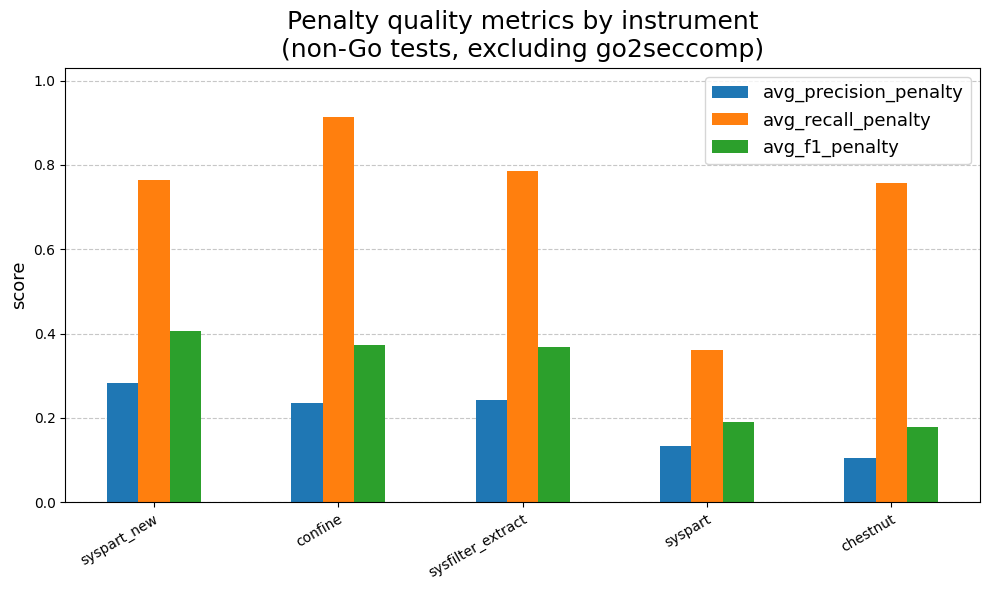

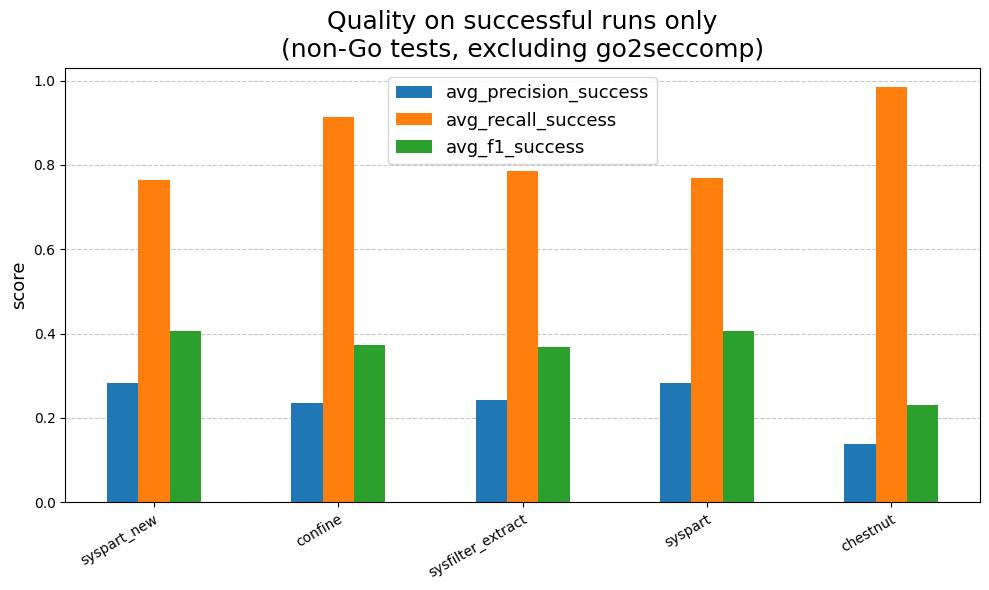

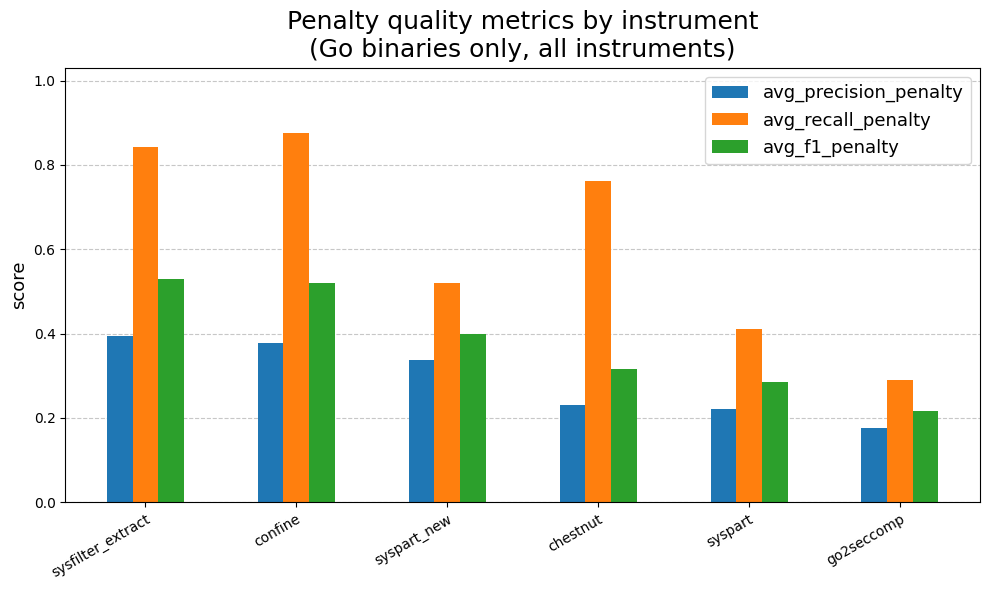

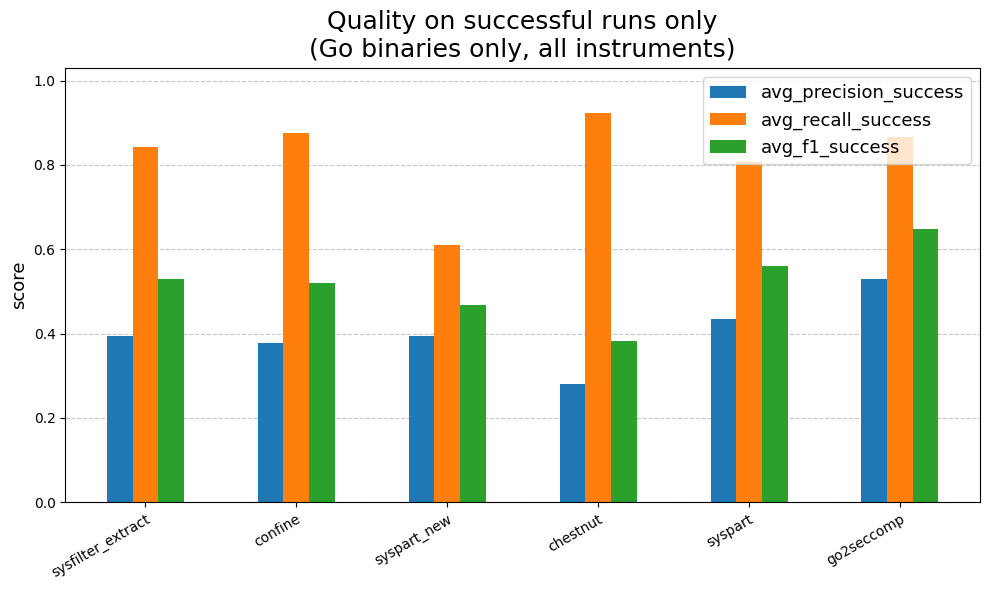

In [17]:
# 2.1–2.4: bar charts

plot_quality_old(
    "2_1_penalty_quality_nongo.csv",
    "Penalty quality metrics by instrument\n(non-Go tests, excluding go2seccomp)",
    legend_loc="upper right",
)

plot_quality_old(
    "2_2_success_quality_nongo.csv",
    "Quality on successful runs only\n(non-Go tests, excluding go2seccomp)",
    legend_loc="upper center",
)

plot_quality_old(
    "2_3_penalty_quality_go.csv",
    "Penalty quality metrics by instrument\n(Go binaries only, all instruments)",
    legend_loc="upper right",
)

plot_quality_old(
    "2_4_success_quality_go.csv",
    "Quality on successful runs only\n(Go binaries only, all instruments)",
    legend_loc="upper right",
)


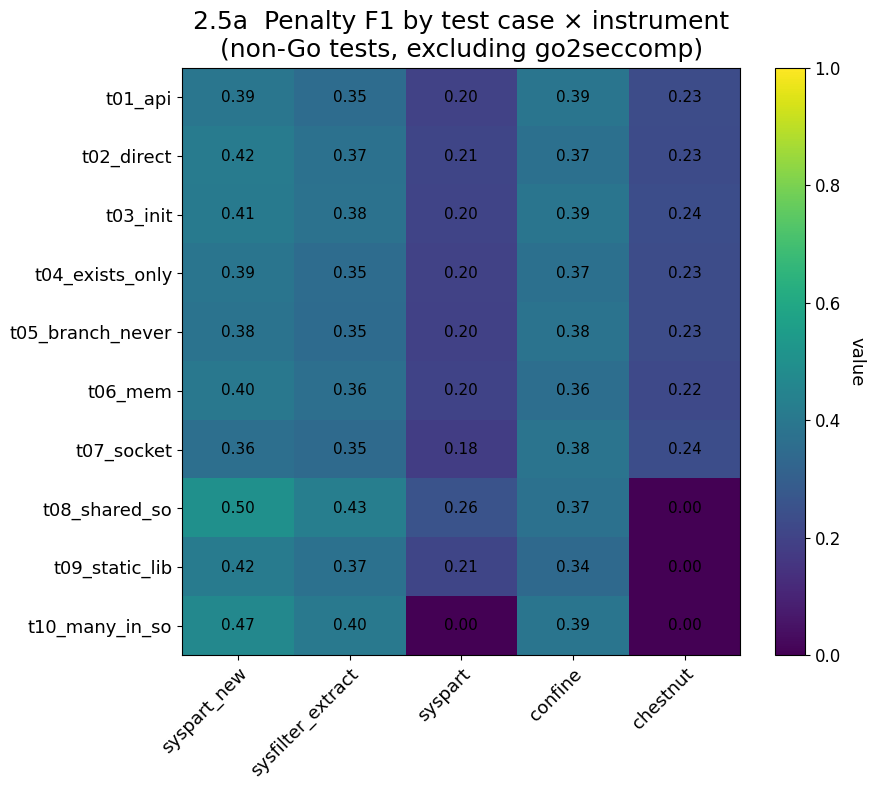

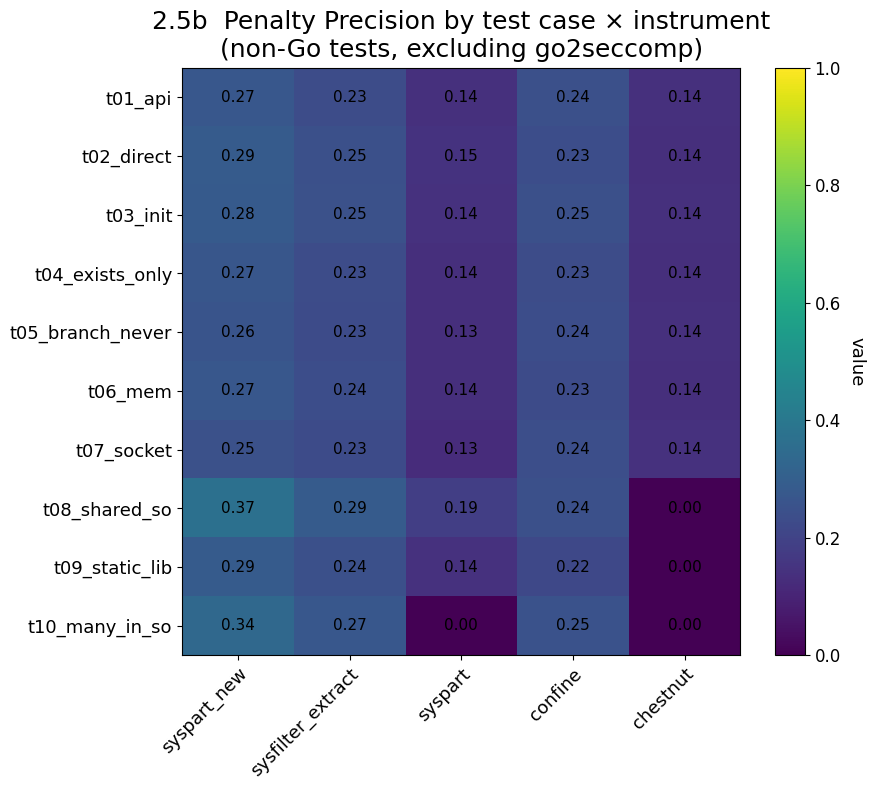

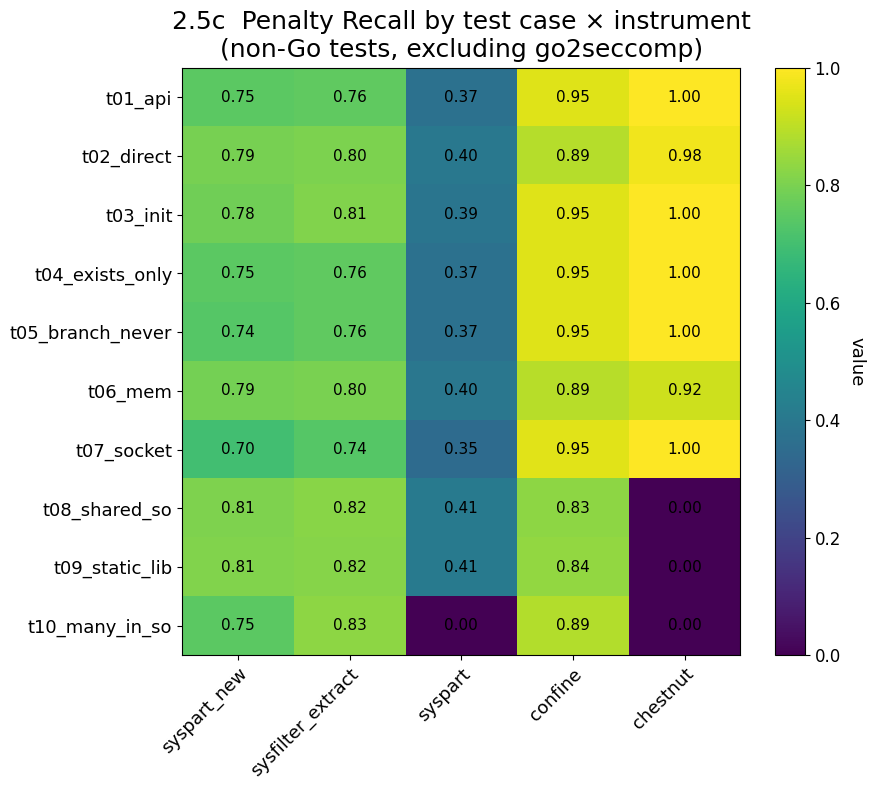

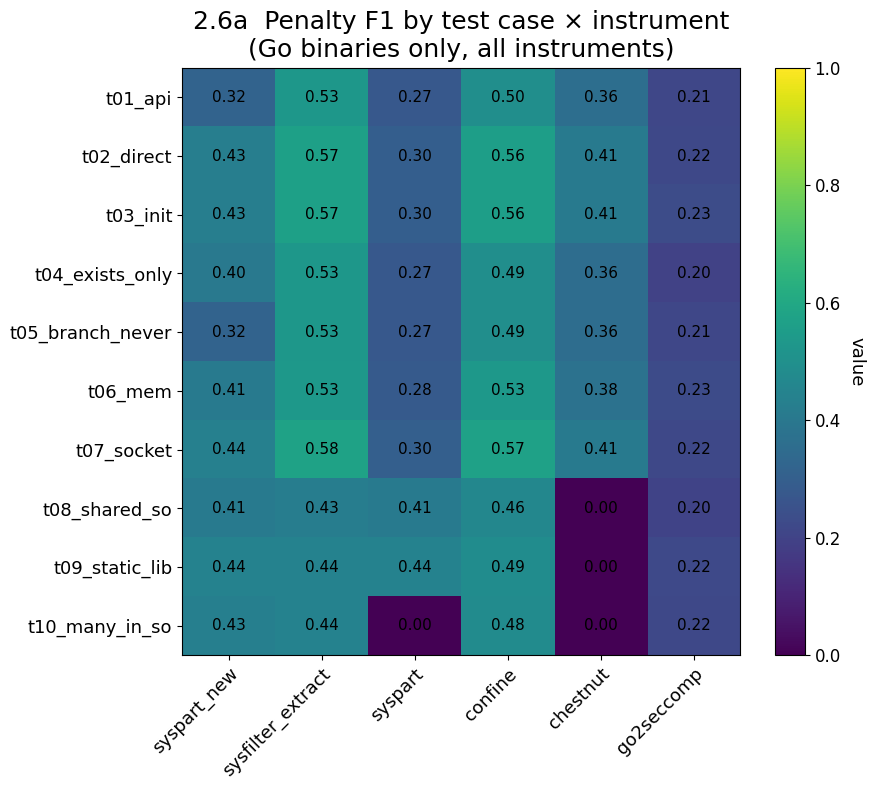

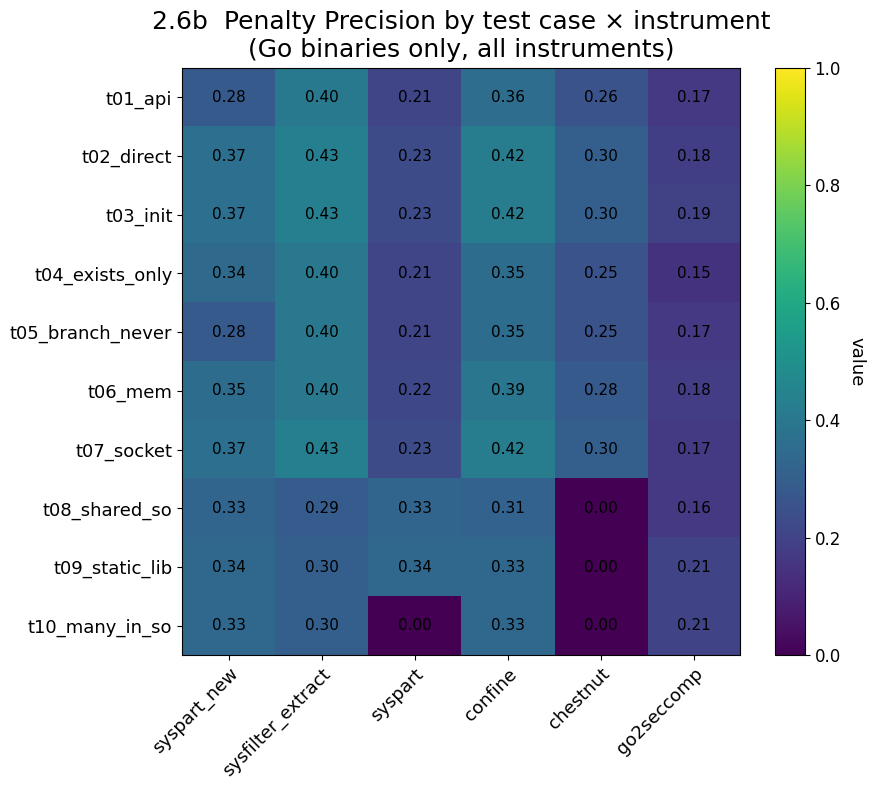

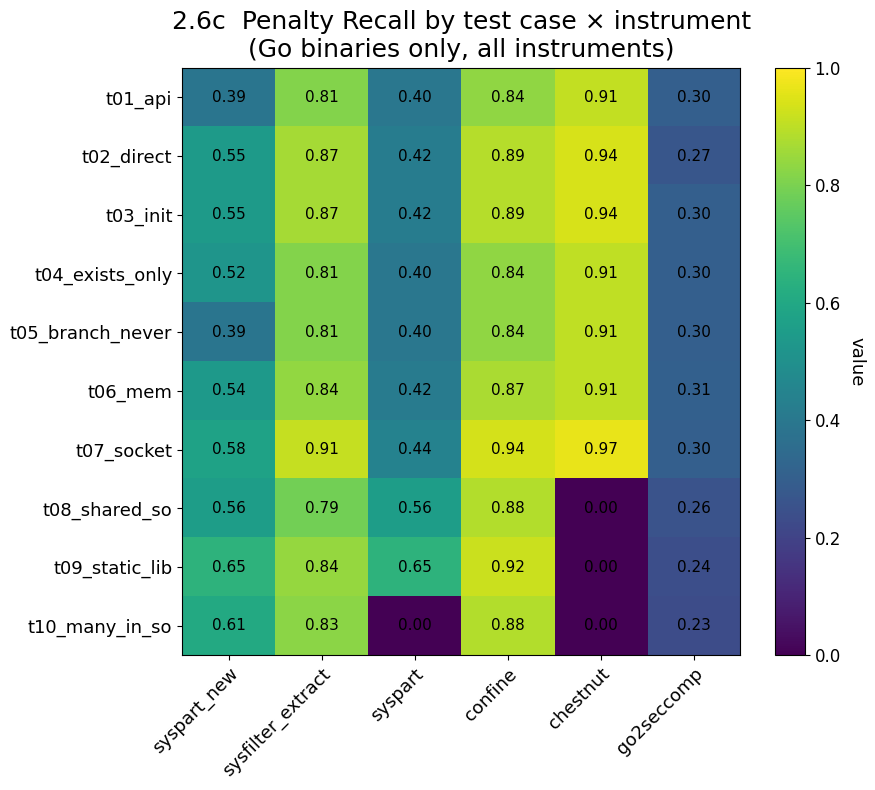

In [18]:
# 2.5–2.6: testcase × instrument heatmaps

plot_heatmap_old(
    "2_5a_f1_by_testcase_nongo.csv",
    "2.5a  Penalty F1 by test case × instrument\n(non-Go tests, excluding go2seccomp)",
)

plot_heatmap_old(
    "2_5b_precision_by_testcase_nongo.csv",
    "2.5b  Penalty Precision by test case × instrument\n(non-Go tests, excluding go2seccomp)",
)

plot_heatmap_old(
    "2_5c_recall_by_testcase_nongo.csv",
    "2.5c  Penalty Recall by test case × instrument\n(non-Go tests, excluding go2seccomp)",
)

plot_heatmap_old(
    "2_6a_f1_by_testcase_go.csv",
    "2.6a  Penalty F1 by test case × instrument\n(Go binaries only, all instruments)",
)

plot_heatmap_old(
    "2_6b_precision_by_testcase_go.csv",
    "2.6b  Penalty Precision by test case × instrument\n(Go binaries only, all instruments)",
)

plot_heatmap_old(
    "2_6c_recall_by_testcase_go.csv",
    "2.6c  Penalty Recall by test case × instrument\n(Go binaries only, all instruments)",
)


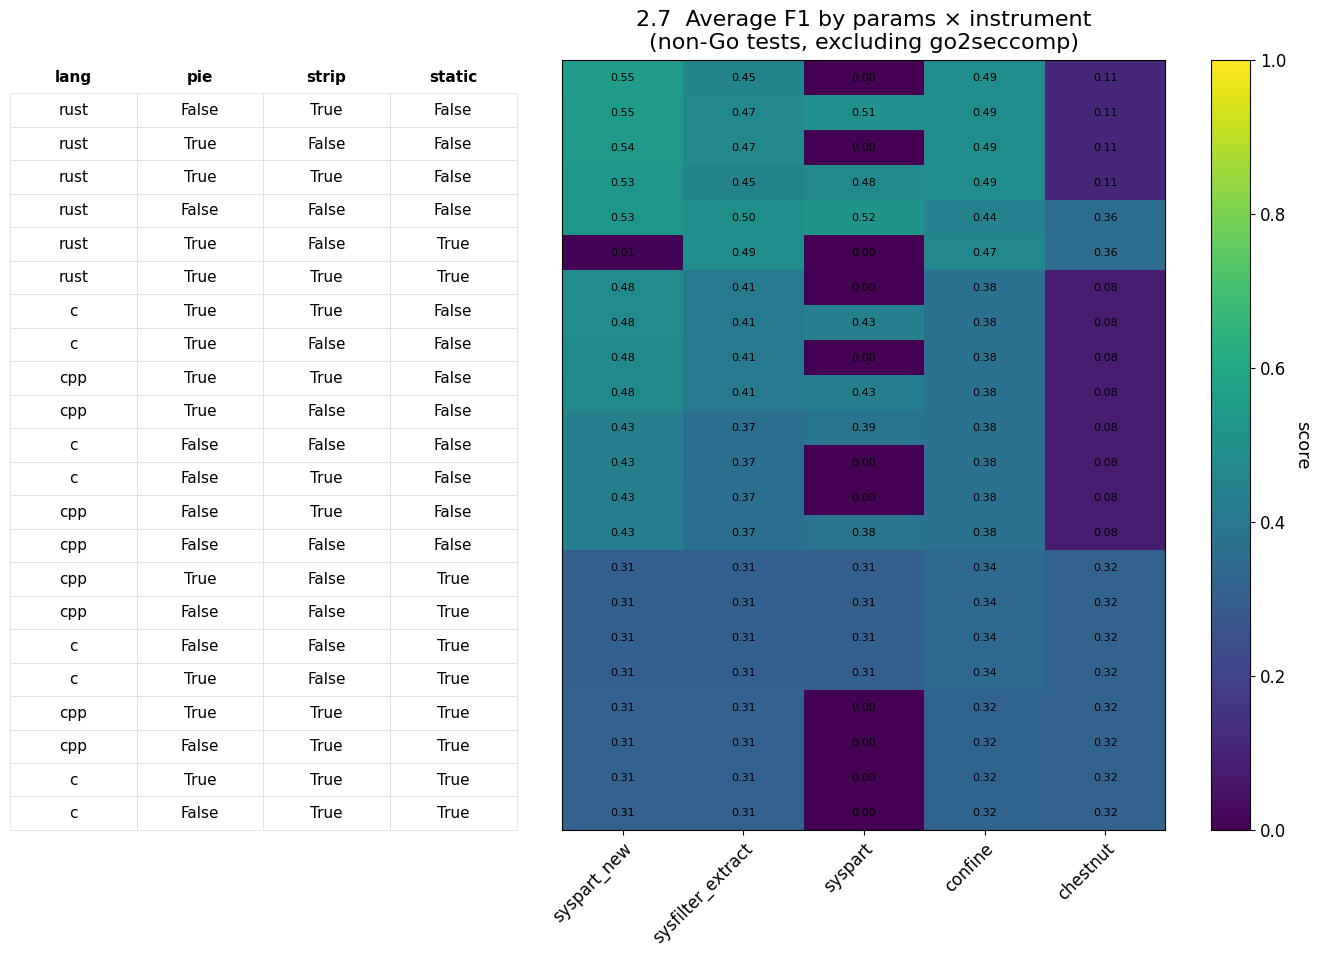

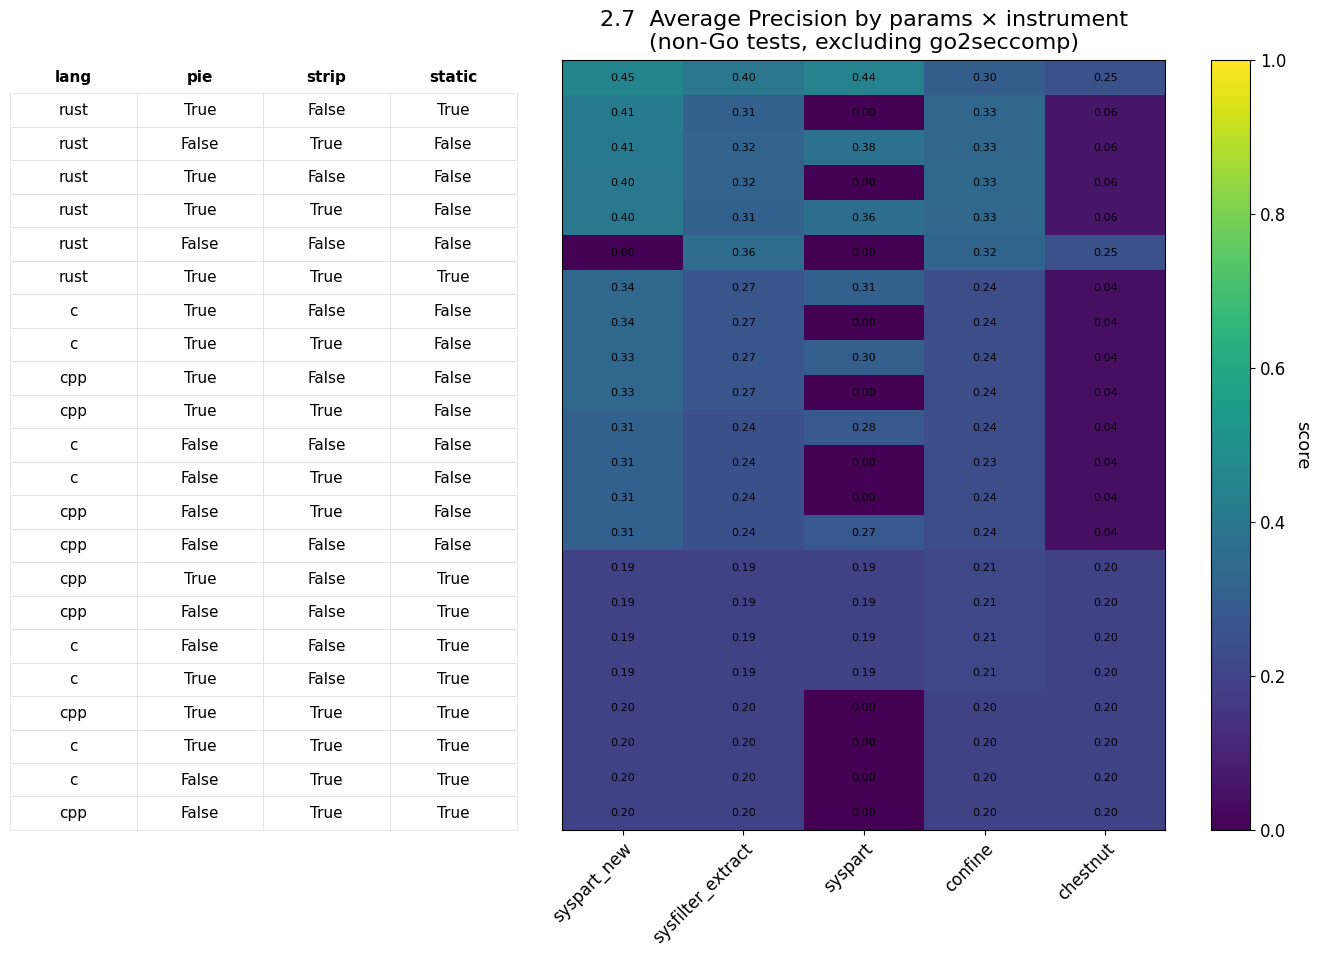

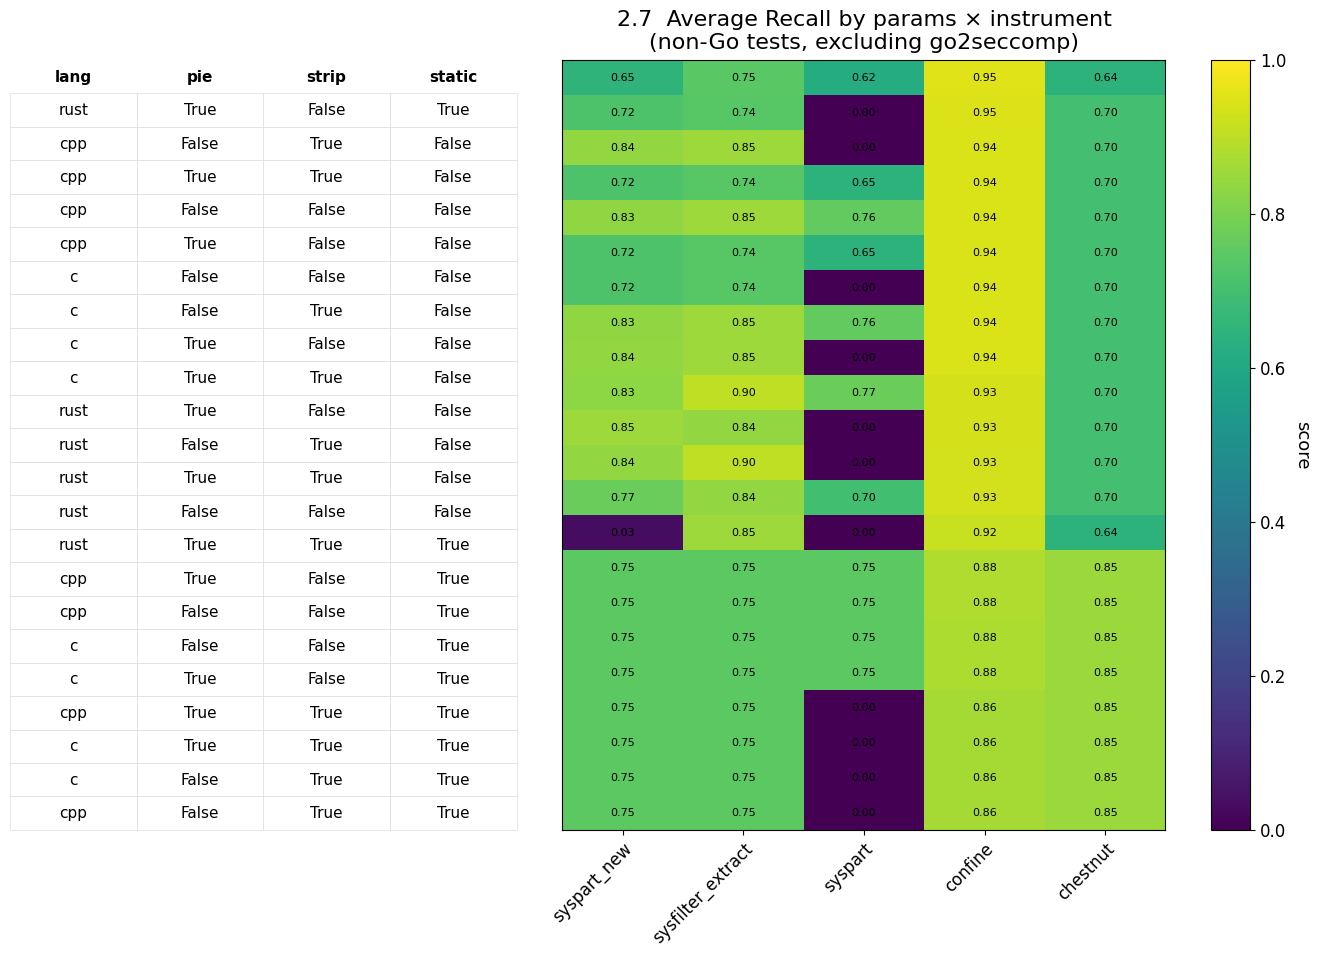

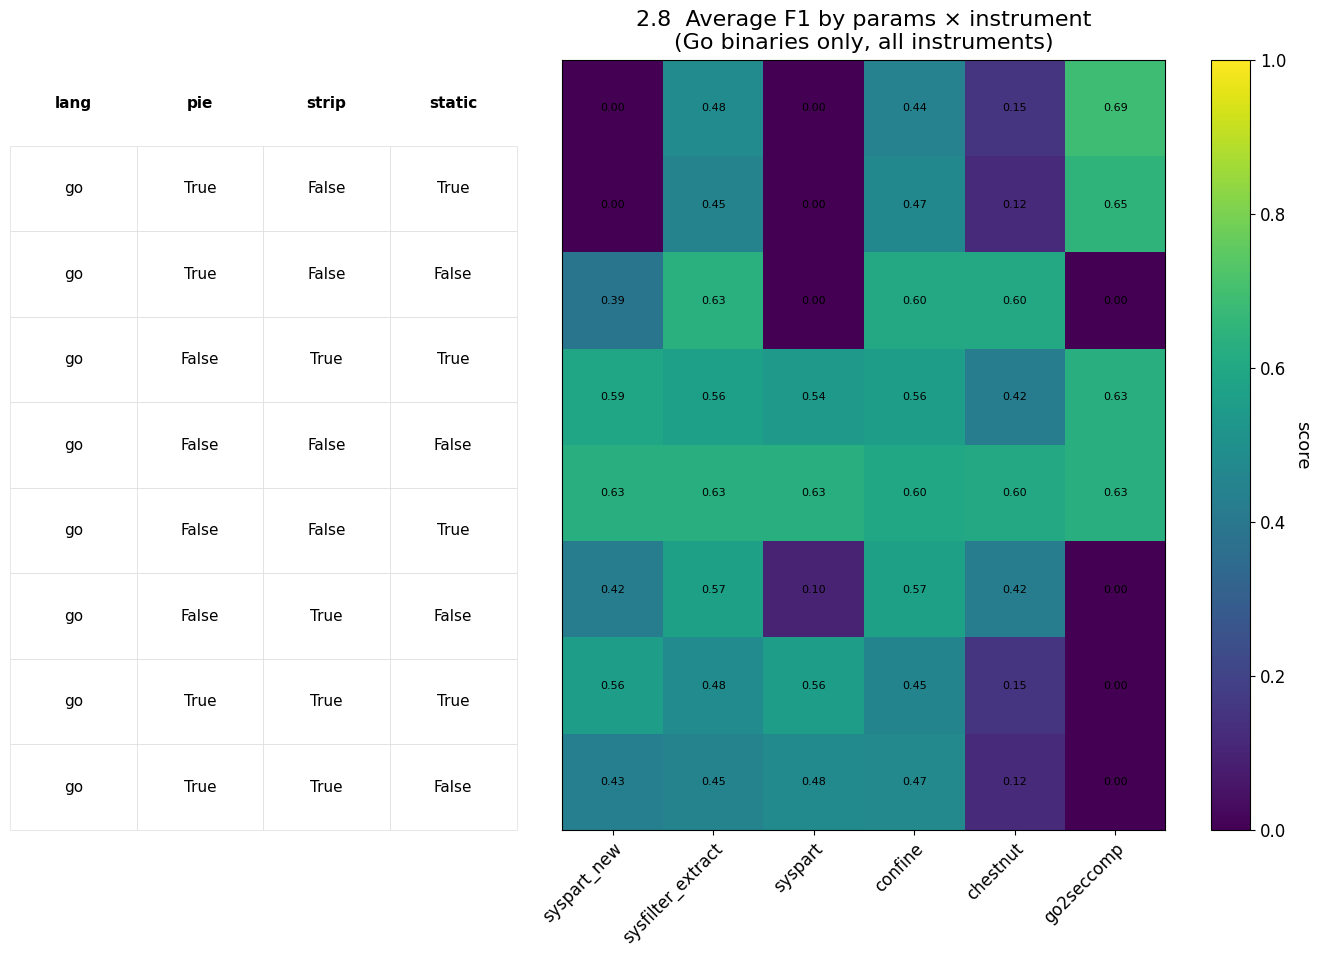

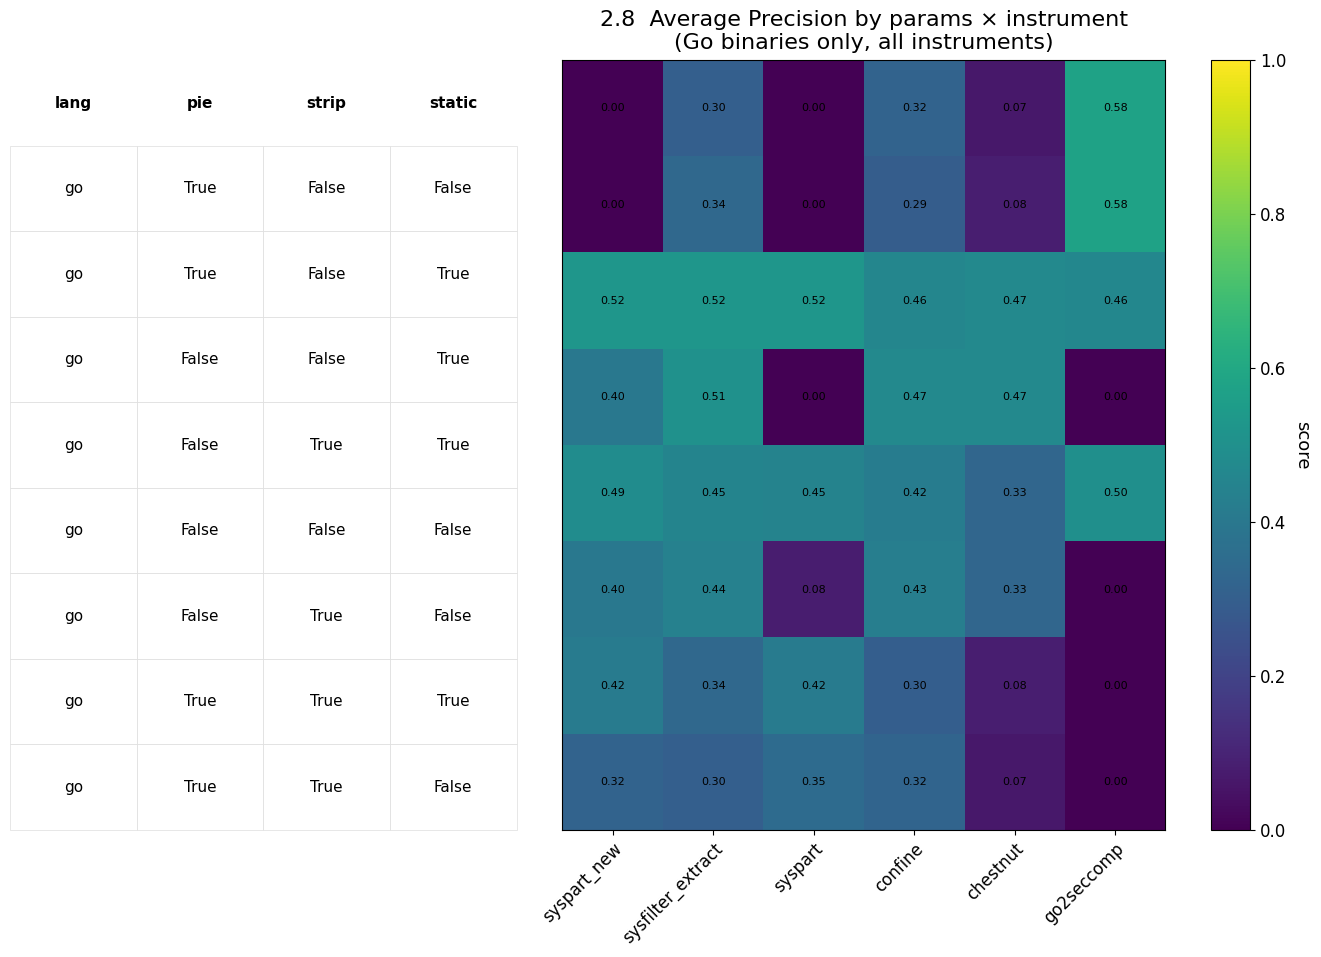

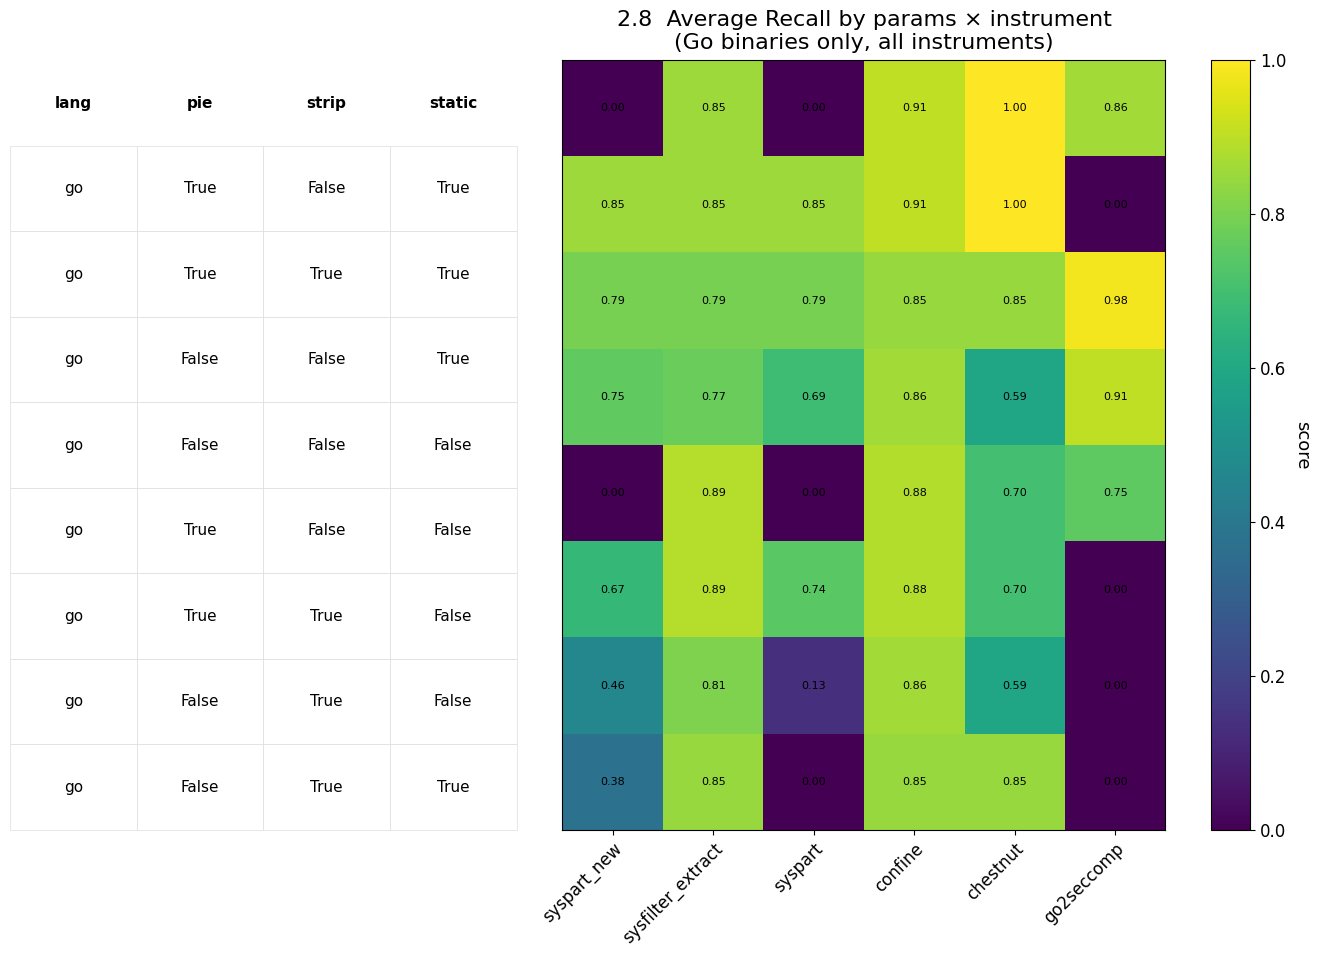

In [19]:
# 2.7–2.8: params table + heatmap

plot_params_heatmap_old(
    "2_7_f1_by_params_nongo.csv",
    "2.7  Average F1 by params × instrument\n(non-Go tests, excluding go2seccomp)",
)

plot_params_heatmap_old(
    "2_7_precision_by_params_nongo.csv",
    "2.7  Average Precision by params × instrument\n(non-Go tests, excluding go2seccomp)",
)

plot_params_heatmap_old(
    "2_7_recall_by_params_nongo.csv",
    "2.7  Average Recall by params × instrument\n(non-Go tests, excluding go2seccomp)",
)

plot_params_heatmap_old(
    "2_8_f1_by_params_go.csv",
    "2.8  Average F1 by params × instrument\n(Go binaries only, all instruments)",
)

plot_params_heatmap_old(
    "2_8_precision_by_params_go.csv",
    "2.8  Average Precision by params × instrument\n(Go binaries only, all instruments)",
)

plot_params_heatmap_old(
    "2_8_recall_by_params_go.csv",
    "2.8  Average Recall by params × instrument\n(Go binaries only, all instruments)",
)
